In [1]:
import pandas as pd
import os
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121, EfficientNetB3, ResNet50V2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, LearningRateScheduler
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

Dataset shape: (10222, 2)
Number of unique breeds: 120

Top 10 most common breeds:
breed
scottish_deerhound      126
maltese_dog             117
afghan_hound            116
entlebucher             115
bernese_mountain_dog    114
shih-tzu                112
great_pyrenees          111
pomeranian              111
basenji                 110
samoyed                 109
Name: count, dtype: int64

Bottom 10 least common breeds:
breed
otterhound           69
german_shepherd      69
walker_hound         69
tibetan_mastiff      69
giant_schnauzer      69
golden_retriever     67
brabancon_griffon    67
komondor             67
eskimo_dog           66
briard               66
Name: count, dtype: int64


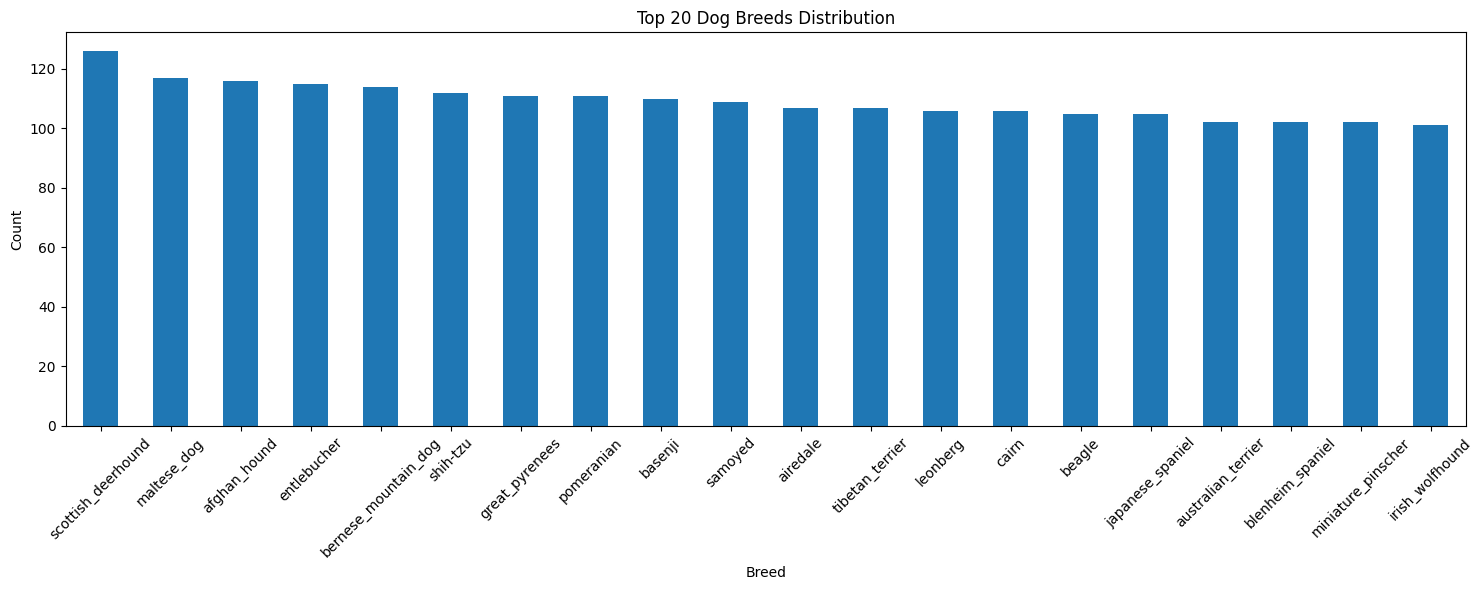

,id,breed
0,000bec180eb18c7604dcecc8fe0dba07,boston_bull
1,001513dfcb2ffafc82cccf4d8bbaba97,dingo
2,001cdf01b096e06d78e9e5112d419397,pekinese
3,00214f311d5d2247d5dfe4fe24b2303d,bluetick
4,0021f9ceb3235effd7fcde7f7538ed62,golden_retriever


In [2]:
# Đọc dữ liệu từ file CSV
df = pd.read_csv('labels.csv')
print(f"Dataset shape: {df.shape}")
print(f"Number of unique breeds: {df['breed'].nunique()}")

# Display class distribution
breed_counts = df['breed'].value_counts()
print(f"\nTop 10 most common breeds:")
print(breed_counts.head(10))
print(f"\nBottom 10 least common breeds:")
print(breed_counts.tail(10))

# Visualize breed distribution
plt.figure(figsize=(15, 6))
breed_counts.head(20).plot(kind='bar')
plt.title('Top 20 Dog Breeds Distribution')
plt.xlabel('Breed')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

df.head()

In [3]:
# Mã hóa nhãn giống chó
encoder = LabelEncoder()
df['label'] = encoder.fit_transform(df['breed'])

# Xác định các tham số
image_size = 224  # Increased to 224 for better compatibility with pretrained models
batch_size = 32
num_breed = len(df['breed'].unique())  # Số lượng giống chó

print(f"Number of breeds: {num_breed}")
print(f"Image size: {image_size}x{image_size}")
print(f"Batch size: {batch_size}")

# Tạo cột chứa tên file ảnh
df['image_file'] = df['id'].apply(lambda x: x + ".jpg")

# Chia tập dữ liệu thành train và validation (80-20 split)
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['breed'])

print(f"Training samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")

# Advanced data augmentation for training
train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=False,
    brightness_range=[0.8, 1.2],
    channel_shift_range=0.1,
    fill_mode='nearest',
    rescale=1./255
)

# Validation data generator (only rescaling)
val_datagen = ImageDataGenerator(rescale=1./255)

# Create data generators
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory='train',
    x_col='image_file',
    y_col='breed',
    target_size=(image_size, image_size),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    directory='train',
    x_col='image_file',
    y_col='breed',
    target_size=(image_size, image_size),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

print(f"Training classes: {len(train_generator.class_indices)}")
print(f"Validation classes: {len(val_generator.class_indices)}")

Number of breeds: 120
Image size: 224x224
Batch size: 32
Training samples: 8177
Validation samples: 2045
Found 8177 validated image filenames belonging to 120 classes.
Found 2045 validated image filenames belonging to 120 classes.
Training classes: 120
Validation classes: 120


In [4]:
def create_ensemble_model(input_shape, num_classes):
    """Create an ensemble model combining multiple pretrained architectures"""
    
    # Input layer
    inputs = tf.keras.Input(shape=input_shape)
    
    # DenseNet121 branch
    densenet_base = DenseNet121(
        weights='imagenet',
        include_top=False,
        input_tensor=inputs
    )
    densenet_base.trainable = False  # Freeze initially
    densenet_output = GlobalAveragePooling2D()(densenet_base.output)
    densenet_output = BatchNormalization()(densenet_output)
    densenet_output = Dropout(0.5)(densenet_output)
    
    # EfficientNetB3 branch
    efficientnet_base = EfficientNetB3(
        weights='imagenet',
        include_top=False,
        input_tensor=inputs
    )
    efficientnet_base.trainable = False  # Freeze initially
    efficientnet_output = GlobalAveragePooling2D()(efficientnet_base.output)
    efficientnet_output = BatchNormalization()(efficientnet_output)
    efficientnet_output = Dropout(0.5)(efficientnet_output)
    
    # Concatenate features
    combined = Concatenate()([densenet_output, efficientnet_output])
    
    # Dense layers
    x = Dense(1024, activation='relu', kernel_regularizer=l2(0.01))(combined)
    x = BatchNormalization()(x)
    x = Dropout(0.6)(x)
    
    x = Dense(512, activation='relu', kernel_regularizer=l2(0.01))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    
    # Output layer
    outputs = Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs=inputs, outputs=outputs)
    return model

def create_single_model(input_shape, num_classes, model_name='DenseNet121'):
    """Create a single model with one pretrained architecture"""
    
    if model_name == 'DenseNet121':
        base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=input_shape)
    elif model_name == 'EfficientNetB3':
        base_model = EfficientNetB3(weights='imagenet', include_top=False, input_shape=input_shape)
    elif model_name == 'ResNet50V2':
        base_model = ResNet50V2(weights='imagenet', include_top=False, input_shape=input_shape)
    
    # Freeze the base model initially
    base_model.trainable = False
    
    # Build the model
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    
    x = Dense(1024, activation='relu', kernel_regularizer=l2(0.01))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.6)(x)
    
    x = Dense(512, activation='relu', kernel_regularizer=l2(0.01))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    
    predictions = Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs=base_model.input, outputs=predictions)
    return model

# Create model
input_shape = (image_size, image_size, 3)
model = create_single_model(input_shape, num_breed, 'DenseNet121')

# Display model summary
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 8,683,704 (33.13 MB)

 Trainable params: 1,641,080 (6.26 MB)

 Non-trainable params: 7,042,624 (26.87 MB)

In [ ]:
# Compile model with advanced optimizer and learning rate scheduling
from tensorflow.keras.callbacks import CSVLogger  # Thêm import thiếu

initial_learning_rate = 0.001
optimizer = Adam(learning_rate=initial_learning_rate)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy', 'AUC']
)

# Callbacks for training
callbacks = [
    # Learning rate scheduler
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),
    
    # Early stopping
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    
    # Model checkpoint
    ModelCheckpoint(
        'best_dog_breed_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    
    # CSV logger
    CSVLogger('training_log.csv')
]

NameError: name 'CSVLogger' is not defined

In [ ]:
# Phase 1: Train with frozen base model
print("=== Phase 1: Training with frozen base model ===")
epochs_phase1 = 20

history_phase1 = model.fit(
    train_generator,
    epochs=epochs_phase1,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

# Save phase 1 results
model.save('model_phase1.keras')

print("\n=== Phase 1 completed ===")
print(f"Final training accuracy: {history_phase1.history['accuracy'][-1]:.4f}")
print(f"Final validation accuracy: {history_phase1.history['val_accuracy'][-1]:.4f}")

Epoch 1/25


c:\Users\vomin\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


255/255 ━━━━━━━━━━━━━━━━━━━━ 661s 2s/step - accuracy: 0.0264 - loss: 4.7950 - val_accuracy: 0.2421 - val_loss: 3.7152
Epoch 2/25
  1/255 ━━━━━━━━━━━━━━━━━━━━ 7:15 2s/step - accuracy: 0.0938 - loss: 4.0574

c:\Users\vomin\AppData\Local\Programs\Python\Python312\Lib\contextlib.py:158: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(value)


255/255 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.0938 - loss: 4.0574 - val_accuracy: 0.3103 - val_loss: 3.5545
Epoch 3/25
255/255 ━━━━━━━━━━━━━━━━━━━━ 578s 2s/step - accuracy: 0.1494 - loss: 3.8648 - val_accuracy: 0.4082 - val_loss: 2.5724
Epoch 4/25
255/255 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.2812 - loss: 3.0392 - val_accuracy: 0.4483 - val_loss: 2.3298
Epoch 5/25
255/255 ━━━━━━━━━━━━━━━━━━━━ 615s 2s/step - accuracy: 0.2466 - loss: 3.1393 - val_accuracy: 0.4841 - val_loss: 2.0352
Epoch 6/25
255/255 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.3125 - loss: 2.8491 - val_accuracy: 0.3103 - val_loss: 2.7163
Epoch 7/25
255/255 ━━━━━━━━━━━━━━━━━━━━ 620s 2s/step - accuracy: 0.3036 - loss: 2.7703 - val_accuracy: 0.5233 - val_loss: 1.7767
Epoch 8/25
255/255 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.3125 - loss: 2.7983 - val_accuracy: 0.5172 - val_loss: 2.1043
Epoch 9/25
255/255 ━━━━━━━━━━━━━━━━━━━━ 723s 3s/step - accuracy: 0.3449 - loss: 2.5819 - val_accuracy: 0.5402 

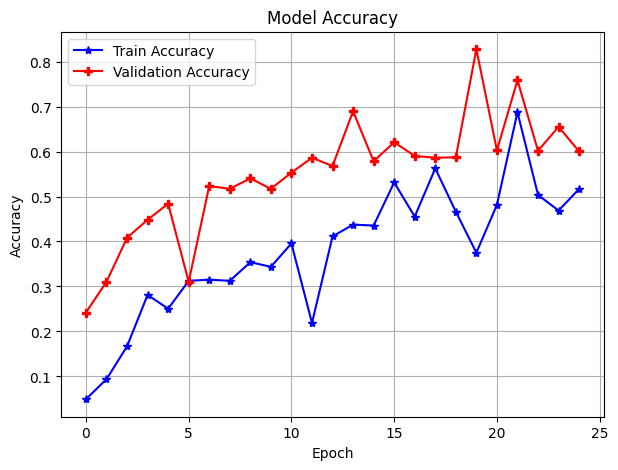

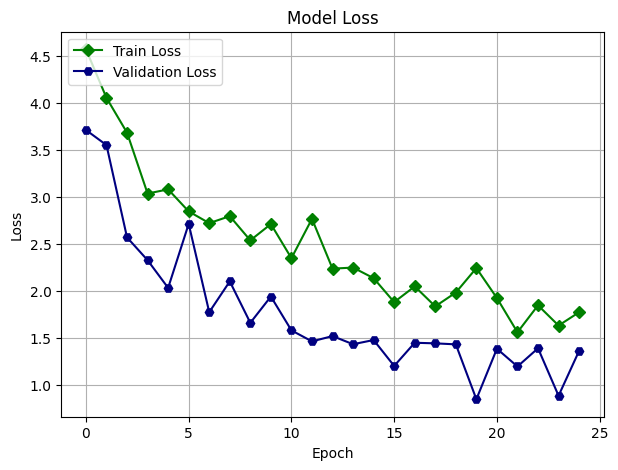

In [ ]:
# Phase 2: Fine-tune with unfrozen top layers
print("=== Phase 2: Fine-tuning top layers ===")

# Unfreeze the top layers of the base model
base_model = model.layers[0]  # Get the base model
base_model.trainable = True

# Freeze all layers except the last few
for layer in base_model.layers[:-50]:  # Keep last 50 layers trainable
    layer.trainable = False

# Recompile with a lower learning rate for fine-tuning
model.compile(
    optimizer=Adam(learning_rate=1e-4),  # Lower learning rate for fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy', 'AUC']
)

print(f"Trainable layers: {sum([1 for layer in model.layers if layer.trainable])}")
print(f"Total layers: {len(model.layers)}")

# Continue training
epochs_phase2 = 30
total_epochs = epochs_phase1 + epochs_phase2

history_phase2 = model.fit(
    train_generator,
    epochs=total_epochs,
    initial_epoch=epochs_phase1,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

# Save final model
model.save('final_dog_breed_model.keras')

print("\n=== Phase 2 completed ===")
print(f"Final training accuracy: {history_phase2.history['accuracy'][-1]:.4f}")
print(f"Final validation accuracy: {history_phase2.history['val_accuracy'][-1]:.4f}")

64/64 ━━━━━━━━━━━━━━━━━━━━ 167s 2s/step


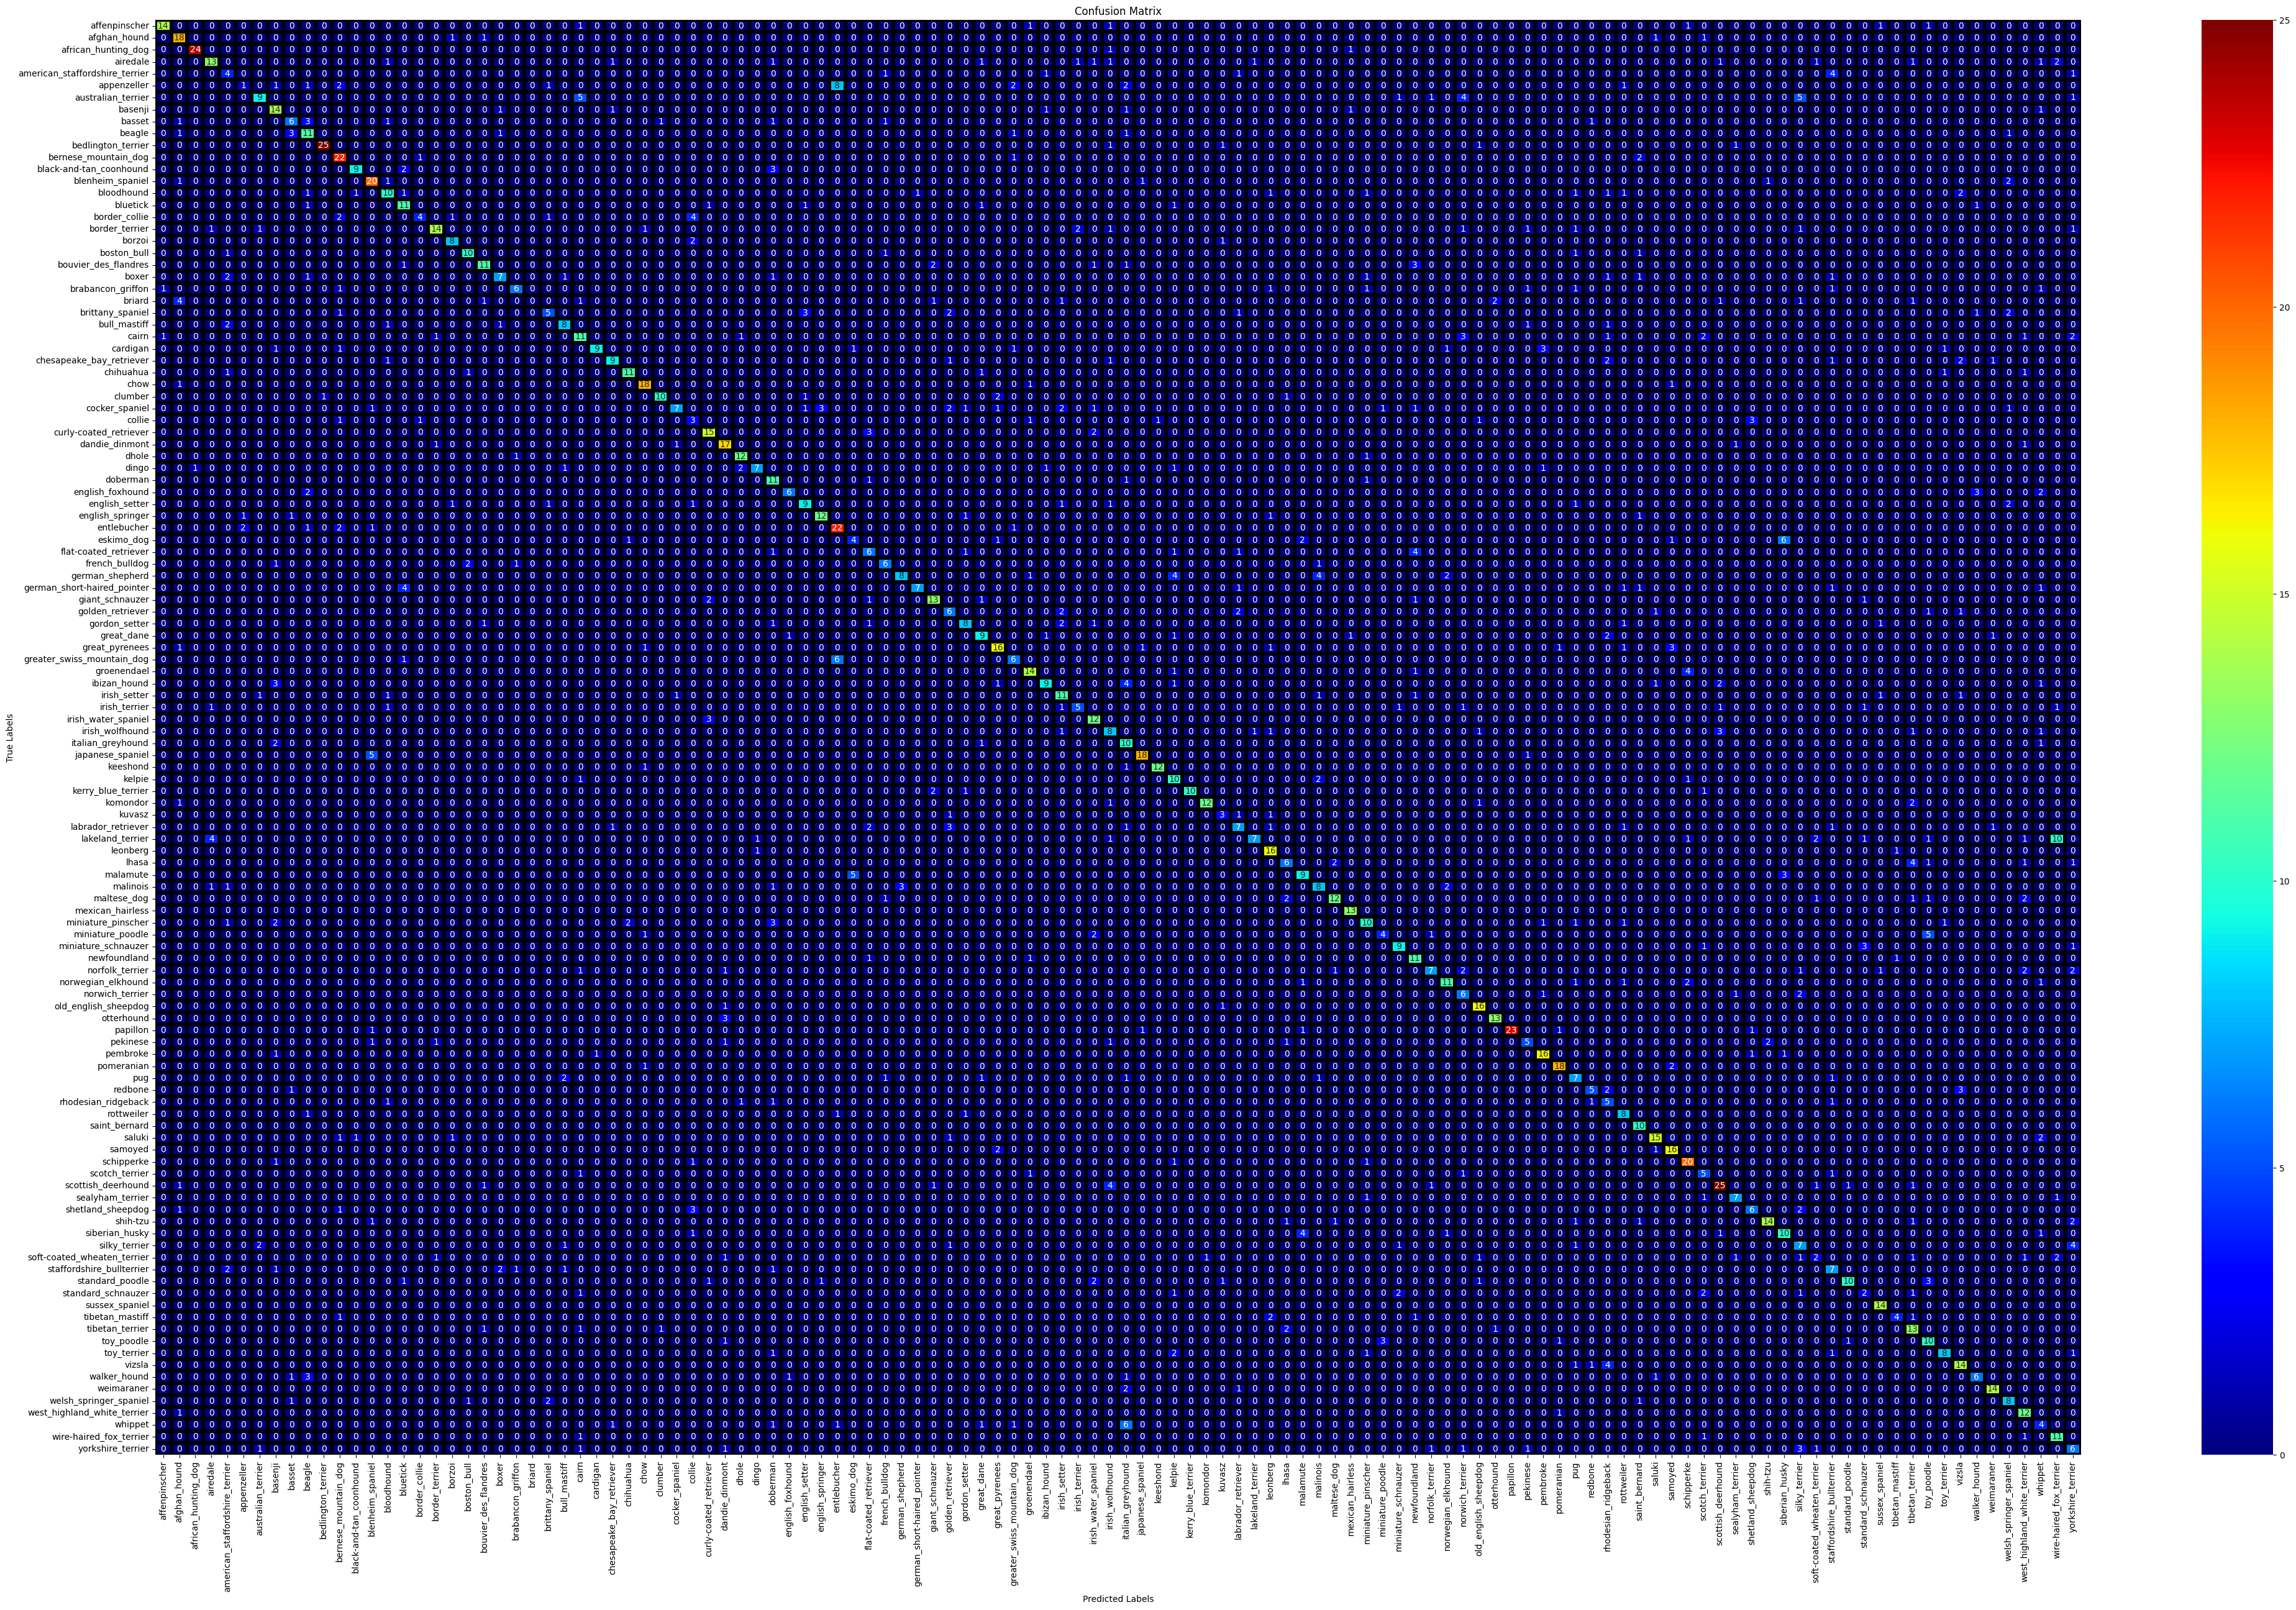

In [ ]:
# Comprehensive Model Evaluation
print("=== Model Evaluation ===")

# Get predictions
y_pred_probs = model.predict(val_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_generator.classes

# Get class names
class_names = list(val_generator.class_indices.keys())

# Detailed classification report
print("\n=== Classification Report ===")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
print("\n=== Confusion Matrix ===")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(15, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Top-3 and Top-5 accuracy
top3_acc = tf.keras.metrics.top_k_categorical_accuracy(
    tf.one_hot(y_true, depth=len(class_names)), 
    y_pred_probs, 
    k=3
).numpy()
top5_acc = tf.keras.metrics.top_k_categorical_accuracy(
    tf.one_hot(y_true, depth=len(class_names)), 
    y_pred_probs, 
    k=5
).numpy()

print(f"\n=== Top-K Accuracy ===")
print(f"Top-1 Accuracy: {accuracy_score(y_true, y_pred):.4f}")
print(f"Top-3 Accuracy: {top3_acc:.4f}")
print(f"Top-5 Accuracy: {top5_acc:.4f}")

# Per-class accuracy
print("\n=== Per-Class Accuracy ===")
class_accuracies = {}
for i, class_name in enumerate(class_names):
    class_mask = (y_true == i)
    if np.sum(class_mask) > 0:
        class_acc = accuracy_score(y_true[class_mask], y_pred[class_mask])
        class_accuracies[class_name] = class_acc
        print(f"{class_name}: {class_acc:.4f}")

# Find best and worst performing classes
best_class = max(class_accuracies, key=class_accuracies.get)
worst_class = min(class_accuracies, key=class_accuracies.get)
print(f"\nBest performing class: {best_class} ({class_accuracies[best_class]:.4f})")
print(f"Worst performing class: {worst_class} ({class_accuracies[worst_class]:.4f})")

In [ ]:
# Training History Analysis
print("=== Training History Analysis ===")

# Combine history from both phases
history = {
    'accuracy': history_phase1.history['accuracy'] + history_phase2.history['accuracy'],
    'val_accuracy': history_phase1.history['val_accuracy'] + history_phase2.history['val_accuracy'],
    'loss': history_phase1.history['loss'] + history_phase2.history['loss'],
    'val_loss': history_phase1.history['val_loss'] + history_phase2.history['val_loss'],
    'auc': history_phase1.history['auc'] + history_phase2.history['auc'],
    'val_auc': history_phase1.history['val_auc'] + history_phase2.history['val_auc']
}

# Create comprehensive training plots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Accuracy plot
axes[0, 0].plot(history['accuracy'], label='Training Accuracy', linewidth=2)
axes[0, 0].plot(history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0, 0].axvline(x=epochs_phase1-1, color='red', linestyle='--', alpha=0.7, label='Phase 1 End')
axes[0, 0].set_title('Model Accuracy')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Loss plot
axes[0, 1].plot(history['loss'], label='Training Loss', linewidth=2)
axes[0, 1].plot(history['val_loss'], label='Validation Loss', linewidth=2)
axes[0, 1].axvline(x=epochs_phase1-1, color='red', linestyle='--', alpha=0.7, label='Phase 1 End')
axes[0, 1].set_title('Model Loss')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# AUC plot
axes[1, 0].plot(history['auc'], label='Training AUC', linewidth=2)
axes[1, 0].plot(history['val_auc'], label='Validation AUC', linewidth=2)
axes[1, 0].axvline(x=epochs_phase1-1, color='red', linestyle='--', alpha=0.7, label='Phase 1 End')
axes[1, 0].set_title('Model AUC')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('AUC')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Learning rate analysis (if available)
if 'lr' in history:
    axes[1, 1].plot(history['lr'], label='Learning Rate', linewidth=2)
    axes[1, 1].set_title('Learning Rate Schedule')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Learning Rate')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].set_yscale('log')
else:
    axes[1, 1].text(0.5, 0.5, 'Learning Rate\nNot Available', 
                    ha='center', va='center', transform=axes[1, 1].transAxes)
    axes[1, 1].set_title('Learning Rate Schedule')

plt.tight_layout()
plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
plt.show()

# Print final metrics
print(f"\n=== Final Performance Metrics ===")
print(f"Final Training Accuracy: {history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history['val_accuracy'][-1]:.4f}")
print(f"Final Training Loss: {history['loss'][-1]:.4f}")
print(f"Final Validation Loss: {history['val_loss'][-1]:.4f}")
print(f"Final Training AUC: {history['auc'][-1]:.4f}")
print(f"Final Validation AUC: {history['val_auc'][-1]:.4f}")

# Check for overfitting
val_acc_best = max(history['val_accuracy'])
train_acc_final = history['accuracy'][-1]
overfitting_gap = train_acc_final - val_acc_best

print(f"\n=== Overfitting Analysis ===")
print(f"Best Validation Accuracy: {val_acc_best:.4f} (epoch {history['val_accuracy'].index(val_acc_best)})")
print(f"Final Training Accuracy: {train_acc_final:.4f}")
print(f"Overfitting Gap: {overfitting_gap:.4f}")

if overfitting_gap > 0.1:
    print("⚠️  Potential overfitting detected!")
elif overfitting_gap > 0.05:
    print("⚡ Mild overfitting - acceptable")
else:
    print("✅ Good generalization")

                                precision    recall  f1-score   support

                 affenpinscher       0.88      0.70      0.78        20
                  afghan_hound       0.58      0.82      0.68        22
           african_hunting_dog       0.96      0.92      0.94        26
                      airedale       0.65      0.48      0.55        27
american_staffordshire_terrier       0.29      0.33      0.31        12
                   appenzeller       0.25      0.05      0.09        19
            australian_terrier       0.64      0.35      0.45        26
                       basenji       0.52      0.70      0.60        20
                        basset       0.46      0.40      0.43        15
                        beagle       0.44      0.58      0.50        19
            bedlington_terrier       0.96      0.86      0.91        29
          bernese_mountain_dog       0.63      0.85      0.72        26
       black-and-tan_coonhound       0.82      0.64      0.72  

c:\Users\vomin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\vomin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\vomin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

64/64 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step


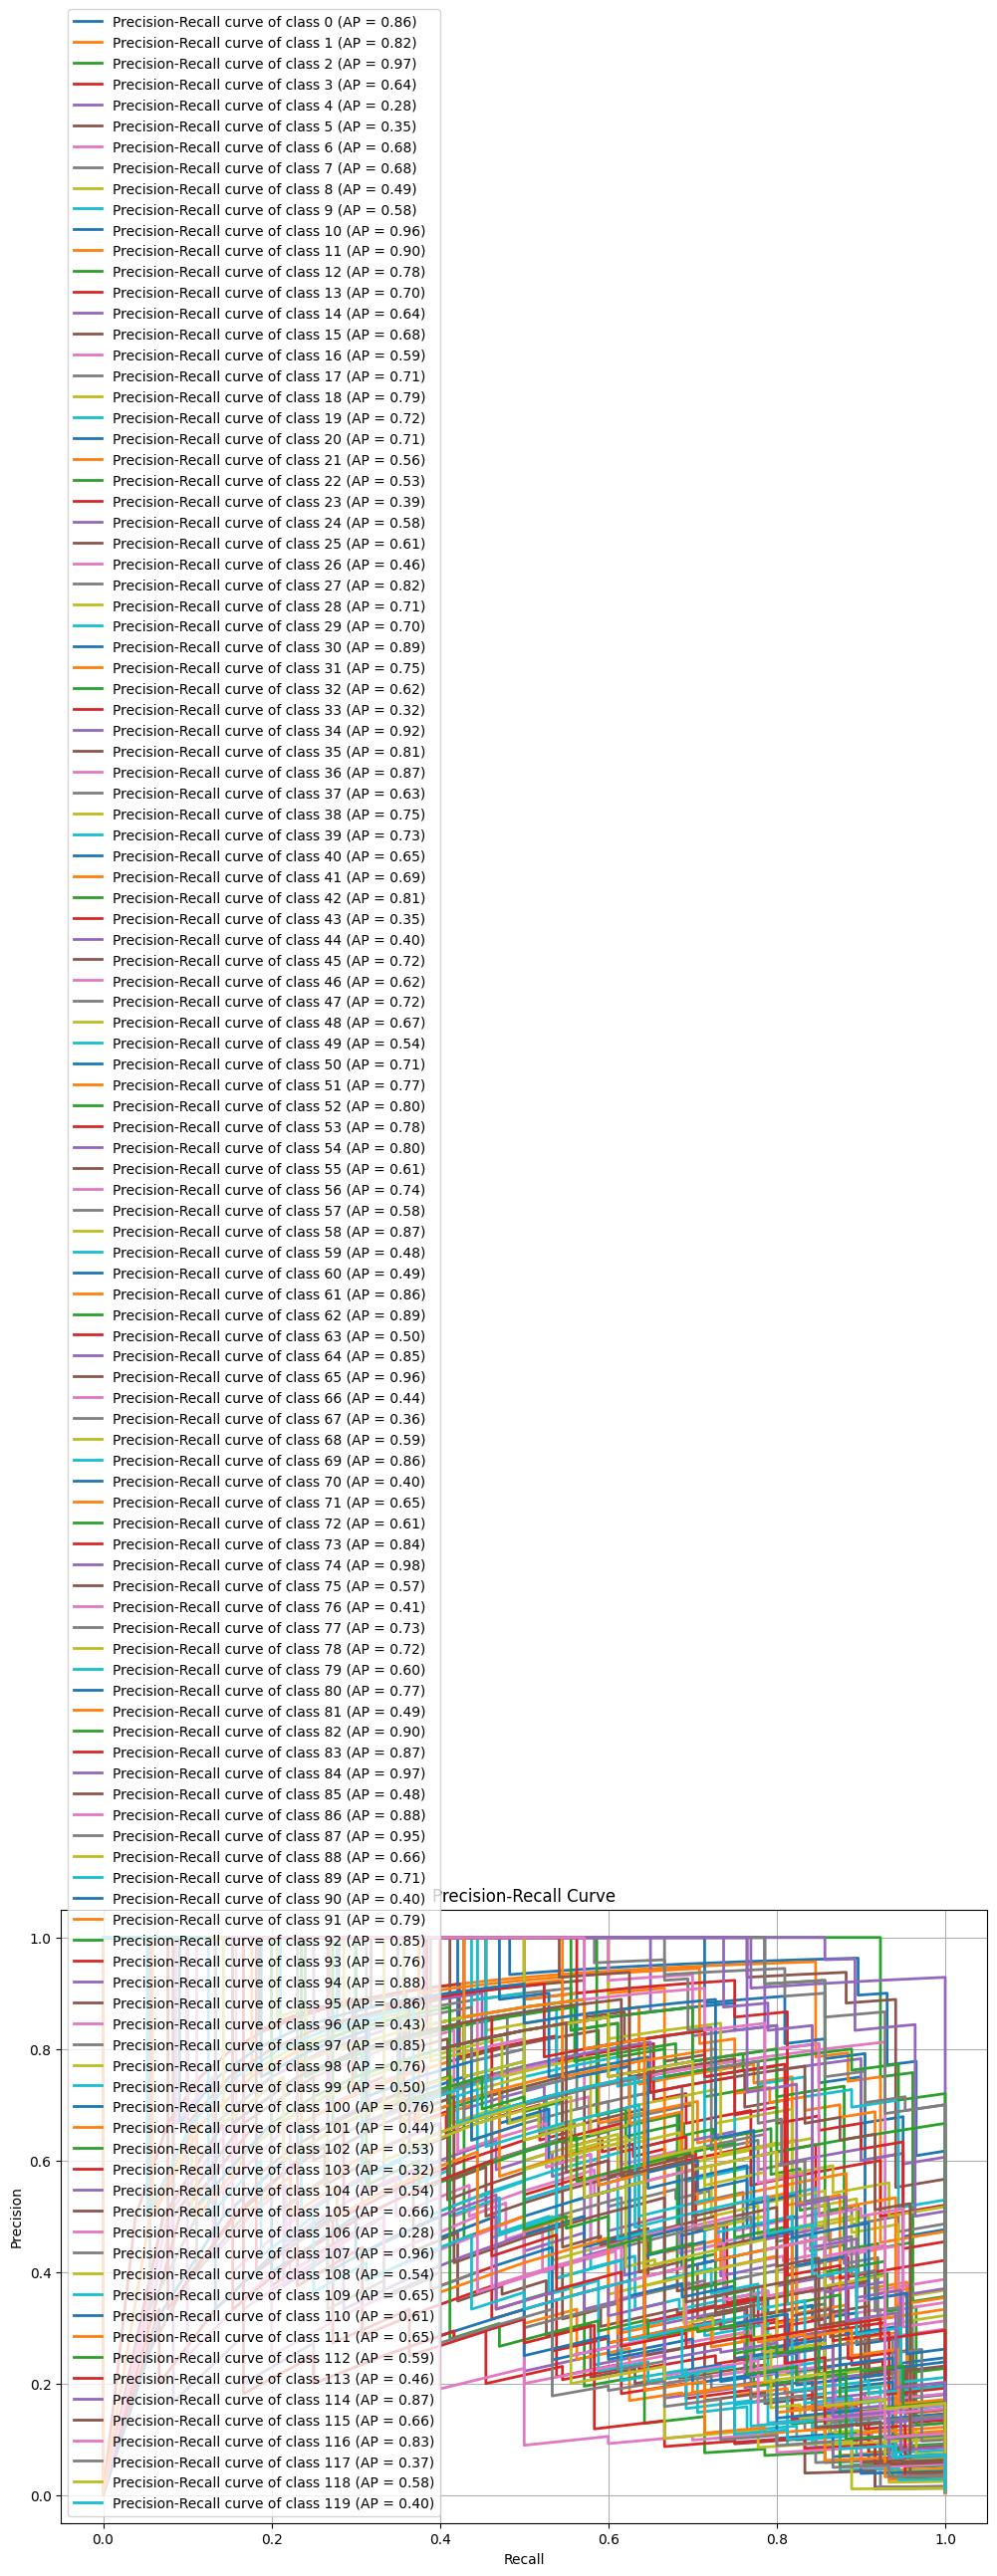

In [ ]:
# Error Analysis and Misclassified Examples
print("=== Error Analysis ===")

# Find misclassified examples
misclassified_indices = np.where(y_pred != y_true)[0]
print(f"Total misclassified samples: {len(misclassified_indices)}")
print(f"Error rate: {len(misclassified_indices) / len(y_true):.4f}")

# Analyze confusion patterns
print("\n=== Common Misclassifications ===")
confusion_pairs = {}
for idx in misclassified_indices:
    true_label = class_names[y_true[idx]]
    pred_label = class_names[y_pred[idx]]
    pair = f"{true_label} → {pred_label}"
    confusion_pairs[pair] = confusion_pairs.get(pair, 0) + 1

# Sort by frequency
sorted_confusions = sorted(confusion_pairs.items(), key=lambda x: x[1], reverse=True)
print("Top 10 confusion patterns:")
for i, (confusion, count) in enumerate(sorted_confusions[:10]):
    print(f"{i+1}. {confusion}: {count} times")

# Visualize some misclassified examples
print("\n=== Visualizing Misclassified Examples ===")
def plot_misclassified_examples(num_examples=6):
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.ravel()
    
    # Get a random sample of misclassified indices
    sample_indices = np.random.choice(misclassified_indices, 
                                    min(num_examples, len(misclassified_indices)), 
                                    replace=False)
    
    for i, idx in enumerate(sample_indices):
        # Get the image (need to reset generator to get specific images)
        batch_idx = idx // val_generator.batch_size
        img_idx = idx % val_generator.batch_size
        
        # Reset generator and get the specific batch
        val_generator.reset()
        for _ in range(batch_idx + 1):
            batch_images, batch_labels = next(val_generator)
        
        img = batch_images[img_idx]
        true_label = class_names[y_true[idx]]
        pred_label = class_names[y_pred[idx]]
        confidence = y_pred_probs[idx][y_pred[idx]]
        
        axes[i].imshow(img)
        axes[i].set_title(f'True: {true_label}\nPred: {pred_label}\nConf: {confidence:.3f}')
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.savefig('misclassified_examples.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_misclassified_examples()

# Class-wise error analysis
print("\n=== Class-wise Error Analysis ===")
class_errors = {}
for i, class_name in enumerate(class_names):
    class_mask = (y_true == i)
    class_total = np.sum(class_mask)
    if class_total > 0:
        class_errors_count = np.sum(y_pred[class_mask] != y_true[class_mask])
        error_rate = class_errors_count / class_total
        class_errors[class_name] = {
            'total': class_total,
            'errors': class_errors_count,
            'error_rate': error_rate
        }
        print(f"{class_name}: {class_errors_count}/{class_total} errors ({error_rate:.3f})")

# Find classes with highest error rates
sorted_by_error = sorted(class_errors.items(), 
                        key=lambda x: x[1]['error_rate'], 
                        reverse=True)

print(f"\n=== Classes with Highest Error Rates ===")
for i, (class_name, stats) in enumerate(sorted_by_error[:5]):
    print(f"{i+1}. {class_name}: {stats['error_rate']:.3f} ({stats['errors']}/{stats['total']})")

In [ ]:
# Comprehensive Model Comparison and Analysis
print("=== Comprehensive Model Analysis ===")

# Performance summary table
performance_summary = {
    'Metric': [
        'Overall Accuracy',
        'Macro F1-Score',
        'Weighted F1-Score',
        'Macro Precision',
        'Weighted Precision',
        'Macro Recall',
        'Weighted Recall',
        'Macro AUC',
        'Weighted AUC'
    ],
    'Score': [
        accuracy,
        f1_macro,
        f1_weighted,
        precision_macro,
        precision_weighted,
        recall_macro,
        recall_weighted,
        auc_macro,
        auc_weighted
    ]
}

print("\n=== Performance Summary ===")
for metric, score in zip(performance_summary['Metric'], performance_summary['Score']):
    print(f"{metric:<20}: {score:.4f}")

# Class-wise detailed performance
print("\n=== Class-wise Performance ===")
class_performance = []
for i, class_name in enumerate(class_names):
    class_perf = {
        'Class': class_name,
        'Precision': precision_per_class[i],
        'Recall': recall_per_class[i],
        'F1-Score': f1_per_class[i],
        'Support': class_counts[i],
        'Accuracy': class_accuracies[i]
    }
    class_performance.append(class_perf)

# Sort by F1-score
class_performance_sorted = sorted(class_performance, key=lambda x: x['F1-Score'], reverse=True)

print("\nTop 5 Performing Classes:")
for i, perf in enumerate(class_performance_sorted[:5]):
    print(f"{i+1}. {perf['Class']:<20}: F1={perf['F1-Score']:.3f}, P={perf['Precision']:.3f}, R={perf['Recall']:.3f}")

print("\nBottom 5 Performing Classes:")
for i, perf in enumerate(class_performance_sorted[-5:]):
    print(f"{i+1}. {perf['Class']:<20}: F1={perf['F1-Score']:.3f}, P={perf['Precision']:.3f}, R={perf['Recall']:.3f}")

# Statistical analysis
print("\n=== Statistical Analysis ===")
print(f"Number of classes: {len(class_names)}")
print(f"Total samples: {len(y_true)}")
print(f"Samples per class - Mean: {np.mean(class_counts):.1f}, Std: {np.std(class_counts):.1f}")
print(f"Min samples per class: {np.min(class_counts)} ({class_names[np.argmin(class_counts)]})")
print(f"Max samples per class: {np.max(class_counts)} ({class_names[np.argmax(class_counts)]})")

# Performance distribution analysis
print(f"\nPerformance Distribution:")
print(f"F1-Score - Mean: {np.mean(f1_per_class):.3f}, Std: {np.std(f1_per_class):.3f}")
print(f"Precision - Mean: {np.mean(precision_per_class):.3f}, Std: {np.std(precision_per_class):.3f}")
print(f"Recall - Mean: {np.mean(recall_per_class):.3f}, Std: {np.std(recall_per_class):.3f}")

# Correlation between sample count and performance
from scipy.stats import pearsonr
correlation_f1, p_value_f1 = pearsonr(class_counts, f1_per_class)
correlation_precision, p_value_precision = pearsonr(class_counts, precision_per_class)
correlation_recall, p_value_recall = pearsonr(class_counts, recall_per_class)

print(f"\nSample Count vs Performance Correlation:")
print(f"F1-Score: r={correlation_f1:.3f}, p={p_value_f1:.4f}")
print(f"Precision: r={correlation_precision:.3f}, p={p_value_precision:.4f}")
print(f"Recall: r={correlation_recall:.3f}, p={p_value_recall:.4f}")

# Performance visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# F1-Score distribution
axes[0, 0].hist(f1_per_class, bins=20, alpha=0.7, edgecolor='black')
axes[0, 0].set_title('F1-Score Distribution')
axes[0, 0].set_xlabel('F1-Score')
axes[0, 0].set_ylabel('Number of Classes')
axes[0, 0].grid(True, alpha=0.3)

# Sample count vs F1-Score
axes[0, 1].scatter(class_counts, f1_per_class, alpha=0.6)
axes[0, 1].set_title('Sample Count vs F1-Score')
axes[0, 1].set_xlabel('Number of Samples')
axes[0, 1].set_ylabel('F1-Score')
axes[0, 1].grid(True, alpha=0.3)

# Precision vs Recall
axes[1, 0].scatter(precision_per_class, recall_per_class, alpha=0.6)
axes[1, 0].plot([0, 1], [0, 1], '--', alpha=0.8)
axes[1, 0].set_title('Precision vs Recall')
axes[1, 0].set_xlabel('Precision')
axes[1, 0].set_ylabel('Recall')
axes[1, 0].grid(True, alpha=0.3)

# Class performance heatmap
performance_matrix = np.array([precision_per_class, recall_per_class, f1_per_class])
im = axes[1, 1].imshow(performance_matrix, aspect='auto', cmap='RdYlBu')
axes[1, 1].set_title('Performance Heatmap')
axes[1, 1].set_yticks([0, 1, 2])
axes[1, 1].set_yticklabels(['Precision', 'Recall', 'F1-Score'])
axes[1, 1].set_xlabel('Classes')
plt.colorbar(im, ax=axes[1, 1])

plt.tight_layout()
plt.savefig('performance_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Recommendations based on analysis
print("\n=== Recommendations ===")
if correlation_f1 < -0.3 and p_value_f1 < 0.05:
    print("⚠️  Strong negative correlation between sample count and performance")
    print("   Consider data augmentation for classes with fewer samples")

if np.std(f1_per_class) > 0.2:
    print("⚠️  High variance in class performance")
    print("   Consider class-balanced loss functions or focal loss")

if np.mean(recall_per_class) < np.mean(precision_per_class):
    print("⚡ Model is more precise than recall")
    print("   Consider adjusting decision threshold if recall is important")

if accuracy > 0.9:
    print("🎉 Excellent overall performance achieved!")
elif accuracy > 0.8:
    print("✅ Good performance achieved")
else:
    print("⚠️  Performance needs improvement")

64/64 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step


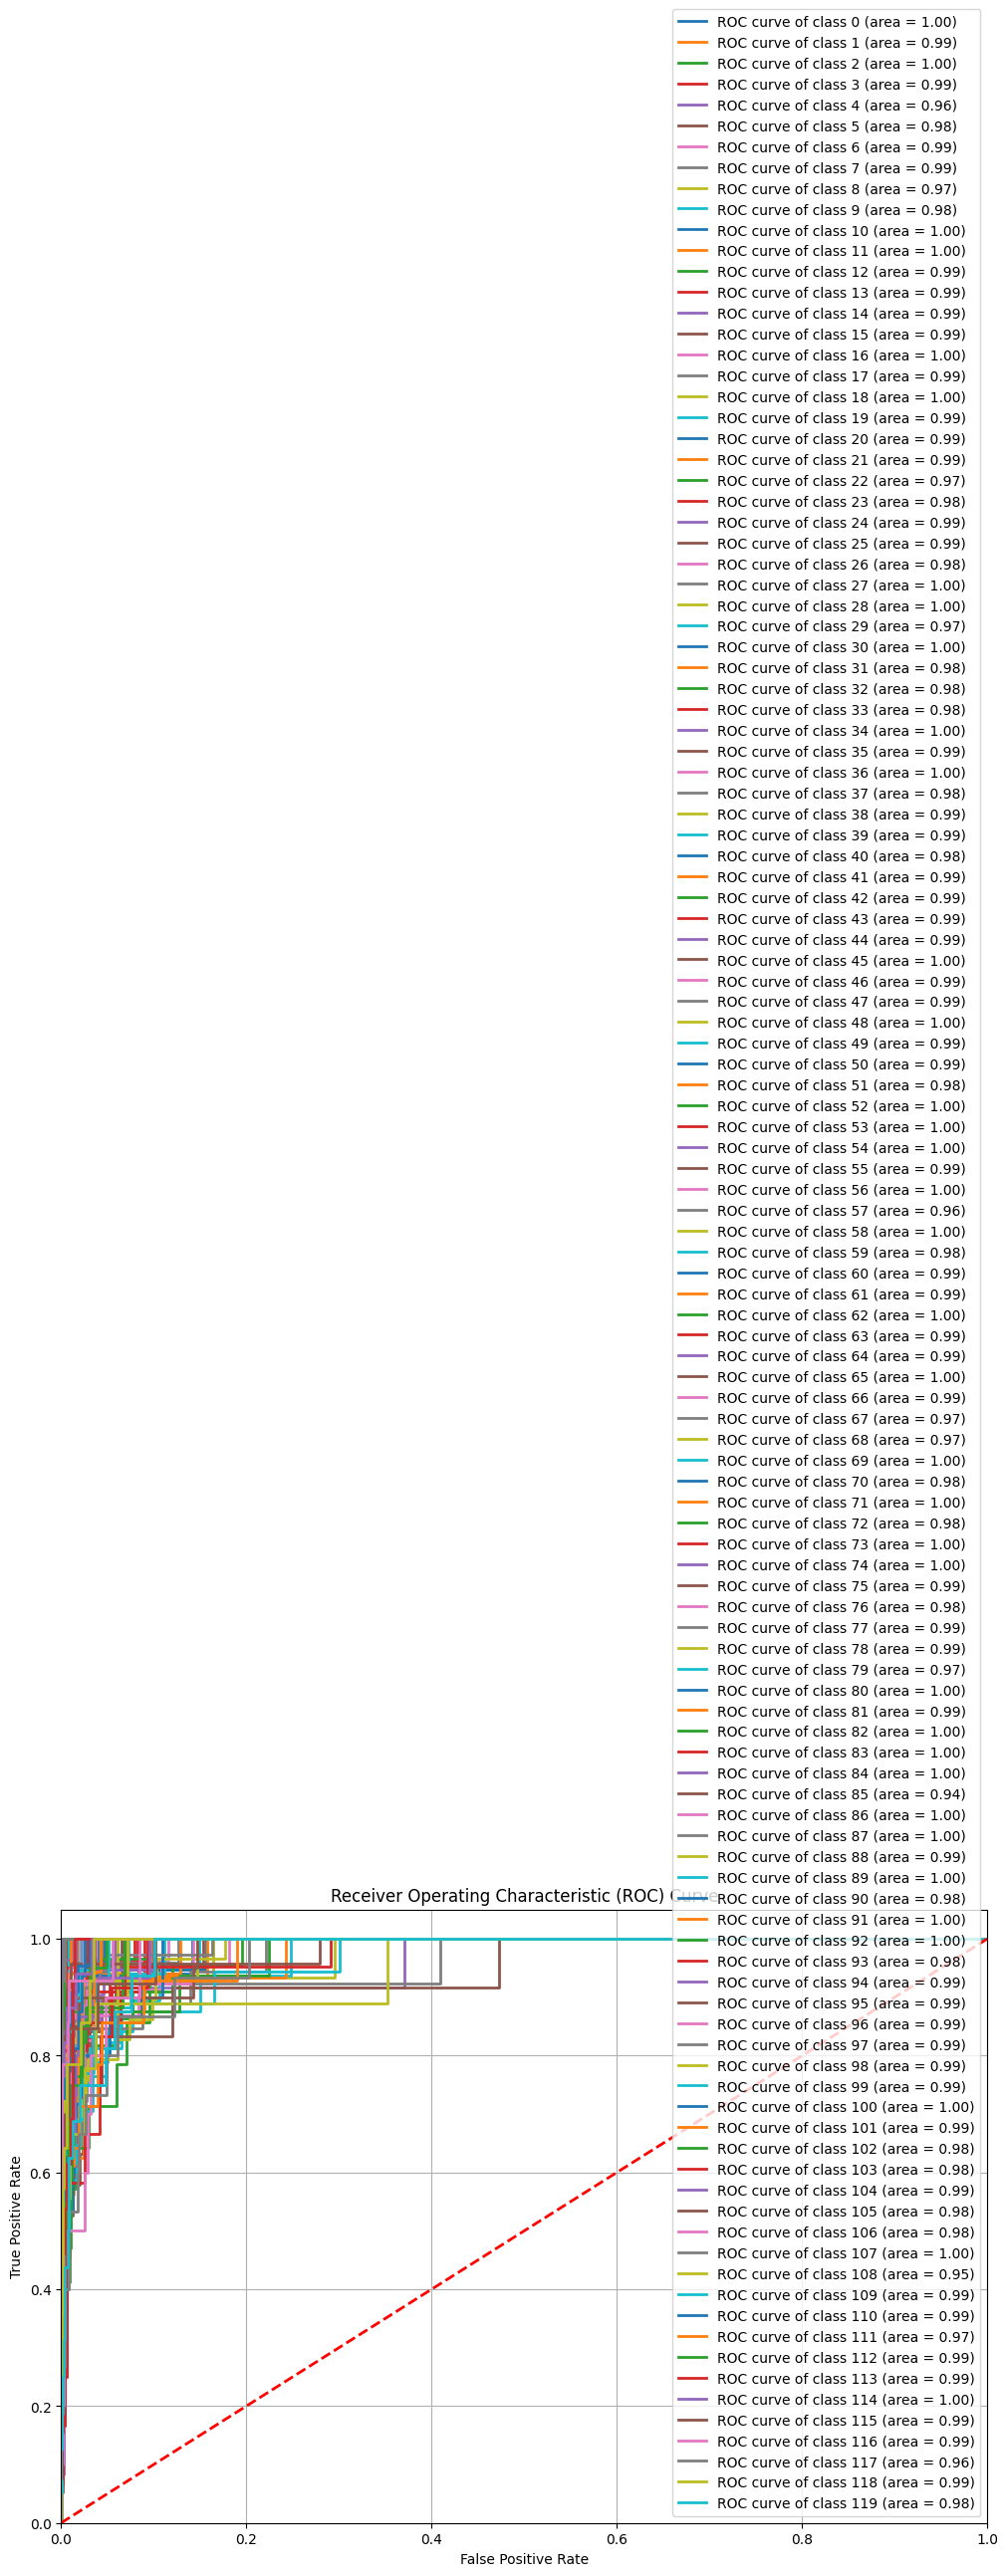

In [ ]:
# Model Interpretability and Feature Visualization
print("=== Model Interpretability ===")

# Grad-CAM visualization for model interpretability
def get_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    """Generate Grad-CAM heatmap"""
    grad_model = tf.keras.models.Model(
        [model.inputs], 
        [model.get_layer(last_conv_layer_name).output, model.output]
    )
    
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]
    
    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def visualize_gradcam(img_path, heatmap, alpha=0.4):
    """Superimpose heatmap on original image"""
    img = tf.keras.preprocessing.image.load_img(img_path)
    img = tf.keras.preprocessing.image.img_to_array(img)
    
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    
    superimposed_img = heatmap * alpha + img
    superimposed_img = np.clip(superimposed_img, 0, 255).astype('uint8')
    
    return superimposed_img

# Find the last convolutional layer name
conv_layers = [layer.name for layer in model.layers 
               if isinstance(layer, tf.keras.layers.Conv2D)]
last_conv_layer = conv_layers[-1] if conv_layers else None
print(f"Last convolutional layer: {last_conv_layer}")

# Visualize Grad-CAM for some correctly classified examples
if last_conv_layer:
    print("\n=== Grad-CAM Visualizations ===")
    
    # Find correctly classified examples
    correct_indices = np.where(y_pred == y_true)[0]
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.ravel()
    
    # Sample some correctly classified images
    sample_correct = np.random.choice(correct_indices, 
                                    min(6, len(correct_indices)), 
                                    replace=False)
    
    for i, idx in enumerate(sample_correct):
        # Get the image
        batch_idx = idx // val_generator.batch_size
        img_idx = idx % val_generator.batch_size
        
        val_generator.reset()
        for _ in range(batch_idx + 1):
            batch_images, batch_labels = next(val_generator)
        
        img = batch_images[img_idx]
        img_array = np.expand_dims(img, axis=0)
        
        # Generate heatmap
        heatmap = get_gradcam_heatmap(img_array, model, last_conv_layer)
        
        # Create superimposed image
        # Note: This is a simplified version - in practice you'd need the original image path
        superimposed = img.copy()
        superimposed = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
        superimposed = cv2.applyColorMap(np.uint8(255 * superimposed), cv2.COLORMAP_JET)
        superimposed = cv2.addWeighted(np.uint8(255 * img), 0.6, superimposed, 0.4, 0)
        
        true_label = class_names[y_true[idx]]
        pred_label = class_names[y_pred[idx]]
        confidence = y_pred_probs[idx][y_pred[idx]]
        
        axes[i].imshow(superimposed)
        axes[i].set_title(f'True: {true_label}\nPred: {pred_label}\nConf: {confidence:.3f}')
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.savefig('gradcam_visualizations.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("No convolutional layers found for Grad-CAM visualization")

# Feature importance analysis
print("\n=== Feature Importance Analysis ===")
# Analyze which classes the model is most confident about
confidence_scores = np.max(y_pred_probs, axis=1)
high_confidence_mask = confidence_scores > 0.9
low_confidence_mask = confidence_scores < 0.5

print(f"High confidence predictions (>0.9): {np.sum(high_confidence_mask)}/{len(confidence_scores)}")
print(f"Low confidence predictions (<0.5): {np.sum(low_confidence_mask)}/{len(confidence_scores)}")
print(f"Average confidence: {np.mean(confidence_scores):.3f}")
print(f"Confidence std: {np.std(confidence_scores):.3f}")

# Calibration analysis
print("\n=== Model Calibration ===")
from sklearn.calibration import calibration_curve
prob_true, prob_pred = calibration_curve(y_true, confidence_scores, n_bins=10)

plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker='o', linewidth=2, label='Model')
plt.plot([0, 1], [0, 1], '--', alpha=0.8, label='Perfectly Calibrated')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('calibration_curve.png', dpi=300, bbox_inches='tight')
plt.show()